In [1]:
import sys
sys.path.append("../")
import importlib

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *


In [2]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cpu"
}

# Data

In [3]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [8]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6378  val_acc=0.789
[002/10] train_loss=0.5916  val_acc=0.789
[003/10] train_loss=0.5712  val_acc=0.789
[004/10] train_loss=0.5782  val_acc=0.789
[005/10] train_loss=0.5539  val_acc=0.789
[006/10] train_loss=0.5595  val_acc=0.789
[007/10] train_loss=0.5497  val_acc=0.789
[008/10] train_loss=0.5429  val_acc=0.789
[009/10] train_loss=0.5167  val_acc=0.842
[010/10] train_loss=0.5250  val_acc=0.842
Test Accuracy: 0.474


# GED Approximator

Generating synthetic GED dataset with 1 perturbations per graph...
Created GED dataset with 188 pairs.


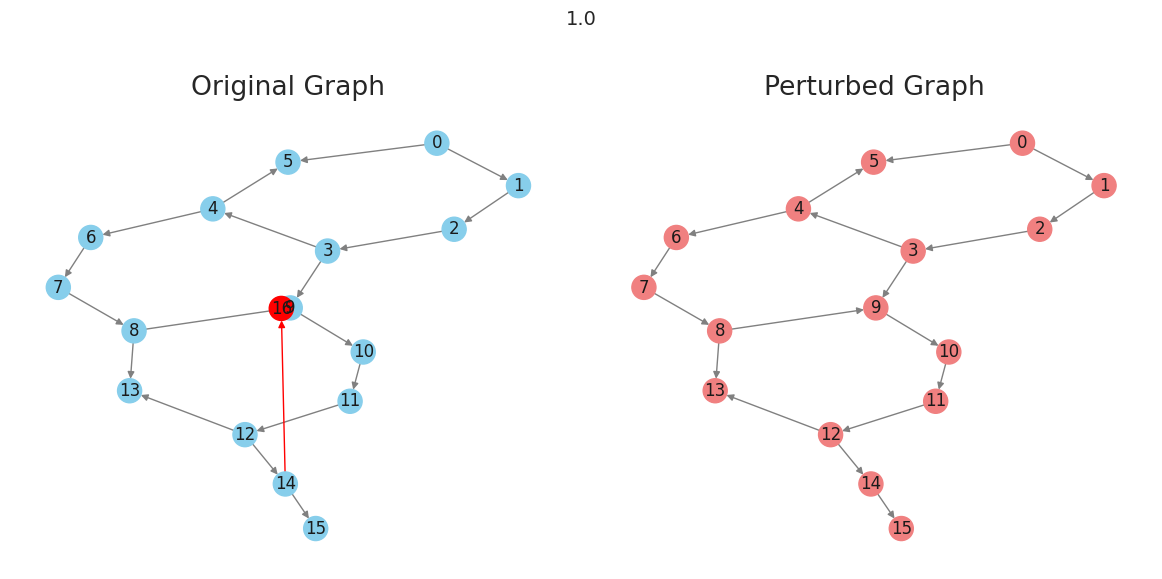

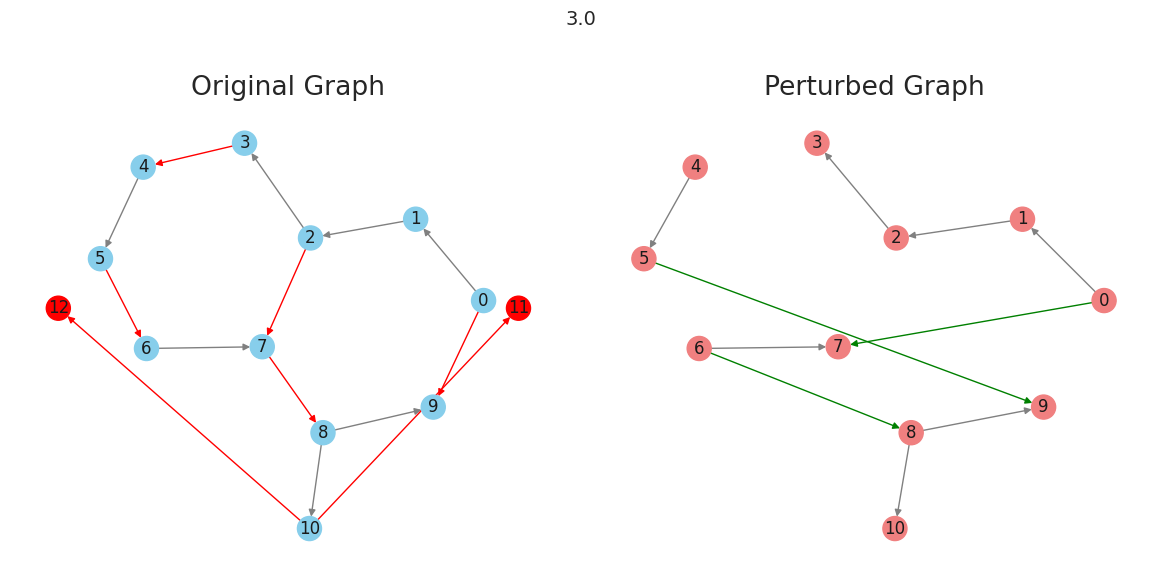

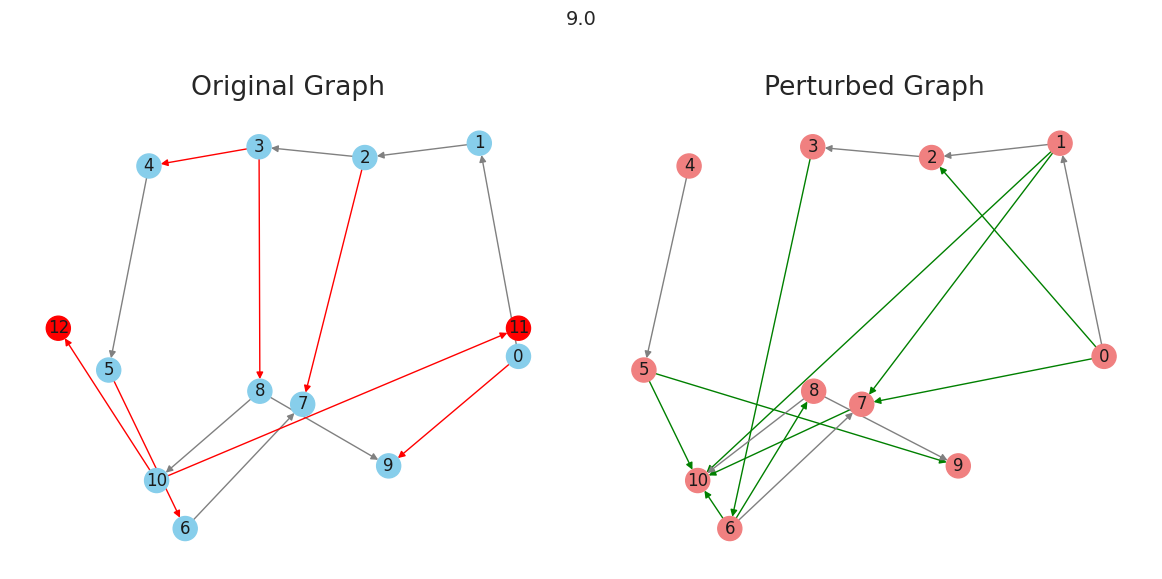

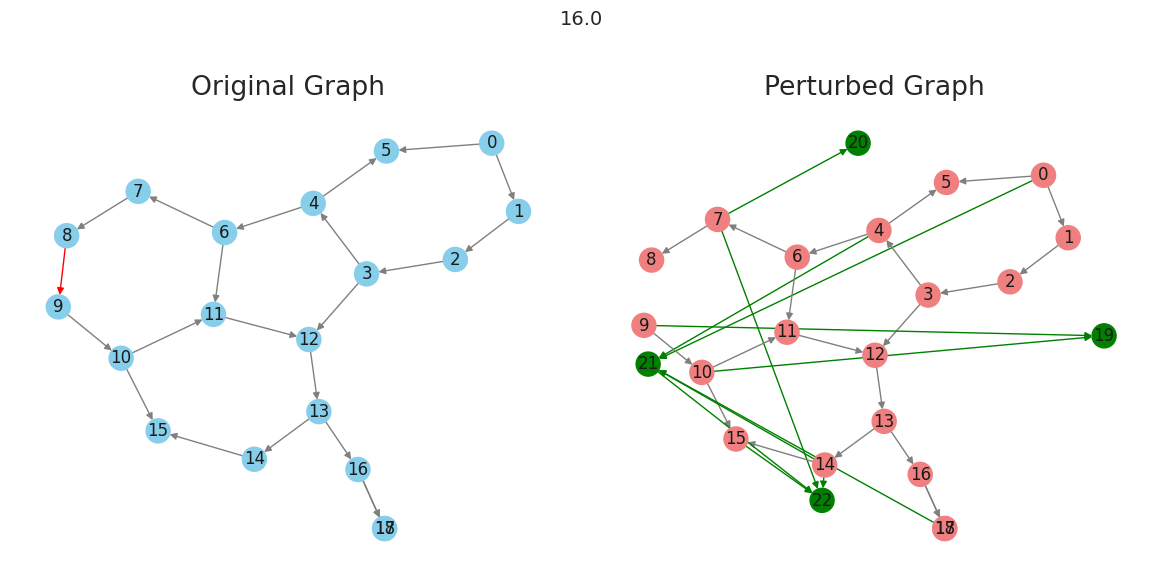

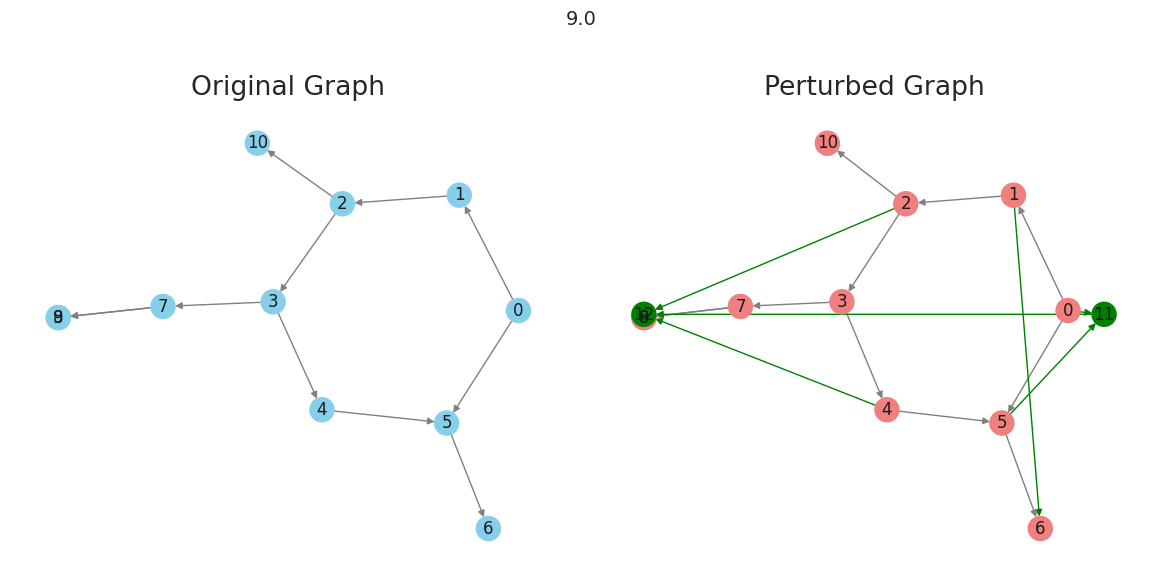

In [9]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=1,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [ ]:
from new_src.simgnn import SimGNN
from new_src.train_simgnn import train 
from new_src.ged_dataset import collate_pairs

model = SimGNN(in_channels=len(data.NODE_CLS))

loader = DataLoader(
    ged_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_pairs,
)

optimizer = torch.optim.Adam(
        model.parameters()
)

for epoch in range(1, 100):
    loss = train(model, loader, optimizer, "cpu")
    print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 001 | Loss: 0.2497
Epoch 002 | Loss: 0.2300
Epoch 003 | Loss: 0.2077
Epoch 004 | Loss: 0.1805
Epoch 005 | Loss: 0.1457
Epoch 006 | Loss: 0.1458
Epoch 007 | Loss: 0.1312
Epoch 008 | Loss: 0.1247
Epoch 009 | Loss: 0.1236
Epoch 010 | Loss: 0.1201
Epoch 011 | Loss: 0.1145
Epoch 012 | Loss: 0.1134
Epoch 013 | Loss: 0.1122
Epoch 014 | Loss: 0.1099
Epoch 015 | Loss: 0.1071
Epoch 016 | Loss: 0.1062
Epoch 017 | Loss: 0.1036
Epoch 018 | Loss: 0.1018
Epoch 019 | Loss: 0.0991
Epoch 020 | Loss: 0.0953
Epoch 021 | Loss: 0.0920
Epoch 022 | Loss: 0.0897
Epoch 023 | Loss: 0.0846
Epoch 024 | Loss: 0.0823
Epoch 025 | Loss: 0.0789
Epoch 026 | Loss: 0.0753
Epoch 027 | Loss: 0.0728
Epoch 028 | Loss: 0.0744
Epoch 029 | Loss: 0.0716
Epoch 030 | Loss: 0.0690
Epoch 031 | Loss: 0.0741
Epoch 032 | Loss: 0.0727
Epoch 033 | Loss: 0.0702
Epoch 034 | Loss: 0.0686
Epoch 035 | Loss: 0.0655
Epoch 036 | Loss: 0.0646
Epoch 037 | Loss: 0.0639
Epoch 038 | Loss: 0.0630
Epoch 039 | Loss: 0.0636
Epoch 040 | Loss: 0.0619


# Generator

In [5]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import dummyDist

In [6]:
def train_generator(cls_idx, data):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=1),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
            dict(key="cont_data", criterion=dummyDist(), weight=1), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
    )

    trainer.train(
        iterations=200,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

In [7]:
import new_src.utils
from new_src.utils import plot_graph
importlib.reload(new_src.utils)



sample = train_generator(0, data), 
plot_graph(sample[0], data)

  0%|          | 0/200 [00:00<?, ?it/s]

DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3], edge_index=[2, 12160], edge_weight=[12160], batch=[640], ptr=[33])
DataBatch(x=[640, 3],

KeyboardInterrupt: 

# Evaluation